## Imports / Data Preparation

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import tarfile
import random
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm

In [ ]:
# To safely store your training progress, use Google Drive:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
tf.device('/GPU:0')

Download CIFAR-10 dataset from the source:

In [ ]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xzvf cifar-10-python.tar.gz

--2024-10-20 08:18:50--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  31.8MB/s    in 5.8s    

2024-10-20 08:18:56 (28.2 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


### Preprocessing

In [ ]:
def load_cifar10_batch(batch_filename):
    with open(batch_filename, 'rb') as f:
        dict = pickle.load(f, encoding='bytes')
        X = dict[b'data']
        Y = dict[b'labels']
        X = X.reshape(-1, 3, 32, 32).astype("float32")
        X = np.transpose(X, (0, 2, 3, 1))  # Convert to NHWC
        Y = np.array(Y)
        return X, Y

def load_cifar10(data_dir):
    X_train = []
    Y_train = []
    # There are 5 training batches
    for i in range(1, 6):
        batch_file = os.path.join(data_dir, f'data_batch_{i}')
        X, Y = load_cifar10_batch(batch_file)
        X_train.append(X)
        Y_train.append(Y)
    X_train = np.concatenate(X_train)
    Y_train = np.concatenate(Y_train)
    # Load test batch
    X_test, Y_test = load_cifar10_batch(os.path.join(data_dir, 'test_batch'))
    return X_train, Y_train, X_test, Y_test

# Specify the path to the extracted CIFAR-10 data
data_dir = 'cifar-10-batches-py'  # Change this path if different

# Load the data
X_train, Y_train, X_test, Y_test = load_cifar10(data_dir)

print(f"Training data shape: {X_train.shape}, Training labels shape: {Y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {Y_test.shape}")

Training data shape: (50000, 32, 32, 3), Training labels shape: (50000,)
Test data shape: (10000, 32, 32, 3), Test labels shape: (10000,)


In [ ]:
# Prepare the dataset
def preprocess_data(X, Y):
    X = X / 255.0  # Normalize to [0,1]
    X = X.astype(np.float32)
    Y = Y.astype(np.int32)
    return X, Y

X_train_p, Y_train_p = preprocess_data(X_train, Y_train)
X_test_p, Y_test_p = preprocess_data(X_test, Y_test)


### Important constants/hyperparameters

Some constants/information about the dataset:

In [ ]:
# Hyperparameters
batch_size = 128
learning_rate = 1e-4

In [ ]:
# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_p, Y_train_p))
train_dataset = train_dataset.shuffle(buffer_size=50000).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_p, Y_test_p))
test_dataset = test_dataset.batch(batch_size)

In [ ]:
image_shape = X_train.shape[1:] # Shape of CIFAR-10 images
image_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']
n_class = len(image_labels)  # Number of classes

### Data Visualization

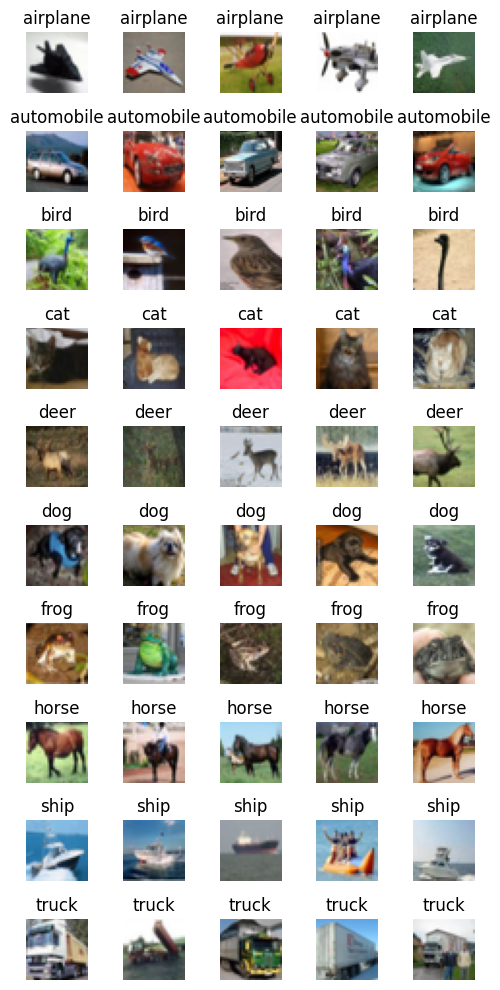

In [ ]:
# [Q1]
plt.figure(figsize=(5, 10))

for class_index in range(n_class):
    class_images = X_train_p[Y_train_p.flatten() == class_index][0:5]

    for i, img in enumerate(class_images):
        plt.subplot(n_class, 5, class_index * 5 + i + 1)
        plt.imshow(img)
        plt.title(image_labels[class_index])
        plt.axis('off')

plt.tight_layout()
plt.show()

## Classification Task

### Model

In [ ]:
# [C1]
class ResBlock(tf.keras.Model):
    def __init__(self, in_channels : int, out_channels : int, downsampling = False):
        super(ResBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.leaky_relu = tf.keras.layers.LeakyReLU()
        self.conv1 = tf.keras.layers.Conv2D(out_channels, kernel_size=3, padding='same', strides=1)
        self.conv2 = tf.keras.layers.Conv2D(out_channels, kernel_size=3, padding='same', strides=1)
        self.conv2_downsampling = tf.keras.layers.Conv2D(out_channels, kernel_size=3, padding='same', strides=2)
        self.downsampling = downsampling
        self.skip = tf.keras.layers.Conv2D(out_channels, kernel_size=1, strides=1, padding='same', use_bias=False)
        self.skip_downsampling = tf.keras.layers.Conv2D(out_channels, kernel_size=1, strides=2, padding='same', use_bias=False)

    def call(self, x):
        identity = x
        x = self.leaky_relu(x)
        x = self.conv1(x)
        x = self.leaky_relu(x)
        if self.in_channels != self.out_channels:
          if self.downsampling:
            x = self.conv2_downsampling(x)
            identity = self.skip_downsampling(identity)
          else:
            x = self.conv2(x)
            identity = self.skip(identity)
        else:
          x = self.conv2(x)
        x += identity
        return x


In [ ]:
# [C2]
import tensorflow as tf

class WRN(tf.keras.Model):
    def __init__(self, num_classes: int = 10):
        super(WRN, self).__init__()
        self.conv = tf.keras.layers.Conv2D(16, kernel_size=3, padding='same', input_shape=(32, 32, 3))
        self.resblock1 = ResBlock(16, 64, downsampling=False)
        self.resblock2 = ResBlock(64, 64, downsampling=False)
        self.resblock3 = ResBlock(64, 128, downsampling=True)
        self.resblock4 = ResBlock(128, 128, downsampling=False)
        self.resblock5 = ResBlock(128, 256, downsampling=True)
        self.resblock6 = ResBlock(256, 256, downsampling=False)
        self.leaky_relu = tf.keras.layers.LeakyReLU()
        self.polling = tf.keras.layers.GlobalAveragePooling2D()
        self.dense = tf.keras.layers.Dense(num_classes, activation='softmax')

    def call(self, x):
        x = self.conv(x)
        x = self.resblock1(x)
        x = self.resblock2(x)
        x = self.resblock3(x)
        x = self.resblock4(x)
        x = self.resblock5(x)
        x = self.resblock6(x)
        x = self.leaky_relu(x)
        x = self.polling(x)
        x = self.dense(x)
        return x

model = WRN(num_classes=10)
model.build((1,32,32,3))
input_data = tf.random.normal((1, 32, 32, 3))
model(input_data)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:372: UserWarning: `build()` was called on layer 'wrn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:372: UserWarning: `build()` was called on layer 'res_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will c

Model: "wrn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (1, 32, 32, 16)             │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ res_block (ResBlock)                 │ ?                           │          47,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ res_block_1 (ResBlock)               │ ?                           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ res_block_2 (ResBlock)               │ ?                           │         229,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ res_block_3 (ResBlock)               │ ?                           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ res_block_4 (ResBlock)               │ ?                           │         918,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ res_block_5 (ResBlock)               │ ?                           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_6 (LeakyReLU)            │ (1, 8, 8, 256)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (1, 256)                    │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (1, 10)                     │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,747,082 (10.48 MB)

 Trainable params: 2,747,082 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

### Part 1 Training

In [ ]:
# [C3]
def part1_train_step(optim : optimizers.Optimizer, model : tf.keras.Model, data : tf.Tensor, label : tf.Tensor, sigma : float = 0.03) -> dict:
    data_np = data.numpy()
    label_np = label.numpy()

    # preprocessing
    noise = np.random.normal(loc=0.0, scale=sigma, size=data_np.shape)
    data_noisy = data_np + noise
    x = np.clip(data_noisy, 0.0, 1.0)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.keras.utils.to_categorical(label_np, num_classes=10)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    # train model
    with tf.GradientTape() as g:
        # calculate loss here
        logits = model(x)
        logits = tf.convert_to_tensor(logits, dtype=tf.float32)
        loss = tf.nn.sigmoid_cross_entropy_with_logits(logits=logits, labels=y)

    # obtain the gradients and apply them (using optimizer)
    grads = g.gradient(loss, model.trainable_variables)
    optim.apply_gradients(zip(grads, model.trainable_variables))

    # return loss (or other values if needed)
    return {
         "loss": tf.reduce_mean(loss)
    }


In [ ]:
def train_loop_1(model, optimizer, train_step, epochs : int = 20, save_interval : int = 5):
    for epoch in range(1, epochs + 1):
        epoch_loss = 0
        num_batches = 0

        # Wrap the training dataset with tqdm to create a progress bar
        with tqdm(train_dataset, unit="batch") as tepoch:
            for step, (batch_x, batch_y) in enumerate(tepoch):
                # Execute a train step and get the losses
                loss_dict = train_step(optimizer, model, batch_x, batch_y)
                epoch_loss += loss_dict["loss"]

                # Accumulate number of batches (for average loss calculation)
                num_batches += 1

                # Update the progress bar description with the current loss
                tepoch.set_description(f"Epoch {epoch}")
                tepoch.set_postfix(**loss_dict)

        # # Uncomment to test accuracy during training (Implement that first!)
        test_accuracy, misclassified_samples = evaluate_accuracy(model, test_dataset, False)
        print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

        avg_loss = epoch_loss / num_batches
        print(f"Epoch {epoch}, Average Loss: {avg_loss:.4f}")

        # Feel free to modify this to save your progress somewhere else
        if epoch % save_interval == 0:
            model.save_weights(f'model-{epoch}.weights.h5')

### Evaluation

In [ ]:
# [C4]
def evaluate_accuracy(model, dataset,show_photo):
    correct_predictions = 0
    total_predictions = 0
    misclassified_samples = []

    for x, y in dataset:
        predictions = model(x, training=False)

        predicted_classes = tf.argmax(predictions, axis=1)
        true_classes = y

        predicted_classes = tf.cast(predicted_classes, tf.int32)
        true_classes = tf.cast(true_classes, tf.int32)

        correct_predictions += tf.reduce_sum(tf.cast(tf.equal(predicted_classes, true_classes), tf.float32)).numpy()
        total_predictions += y.shape[0]
        if show_photo:
          for i in range(y.shape[0]):
              if predicted_classes[i] != true_classes[i]:
                  misclassified_samples.append((x[i].numpy(), true_classes[i].numpy(), predicted_classes[i].numpy()))

    accuracy = correct_predictions / total_predictions
    return accuracy, misclassified_samples

### Execute training

In [ ]:
# Instantiate the model
model = WRN(num_classes=n_class)

# Define the optimizer
optimizer = optimizers.Adam(learning_rate=learning_rate)

In [ ]:
# uncomment to run the code. I commend it as it takes too long to run the code. I afraid I may misclick it
train_loop_1(model, optimizer, part1_train_step, 20)

Epoch 1: 100%|██████████| 391/391 [01:37<00:00,  4.01batch/s, loss=tf.Tensor(0.71896625, shape=(), dtype=float32)]


Test Accuracy: 34.94%
Epoch 1, Average Loss: 0.7232


Epoch 2: 100%|██████████| 391/391 [01:23<00:00,  4.67batch/s, loss=tf.Tensor(0.7013967, shape=(), dtype=float32)]


Test Accuracy: 43.32%
Epoch 2, Average Loss: 0.7141


Epoch 3: 100%|██████████| 391/391 [01:23<00:00,  4.67batch/s, loss=tf.Tensor(0.7069198, shape=(), dtype=float32)]


...

Test Accuracy: 68.18%
Epoch 18, Average Loss: 0.6849


Epoch 19: 100%|██████████| 391/391 [01:24<00:00,  4.61batch/s, loss=tf.Tensor(0.6841235, shape=(), dtype=float32)]


Test Accuracy: 68.83%
Epoch 19, Average Loss: 0.6840


Epoch 20: 100%|██████████| 391/391 [01:24<00:00,  4.62batch/s, loss=tf.Tensor(0.677791, shape=(), dtype=float32)]


Test Accuracy: 67.68%
Epoch 20, Average Loss: 0.6834


Test Accuracy: 67.68%


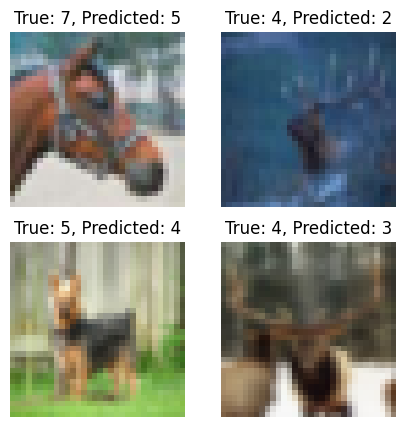

In [ ]:
# [Q5] Report the accuracy of the test dataset and show at least 4 misclassified samples
test_accuracy, misclassified_samples = evaluate_accuracy(model, test_dataset,True)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

num_samples_to_show = 4
plt.figure(figsize=(5, 5))
for i in range(num_samples_to_show):
    img, true_label, predicted_label = misclassified_samples[i]
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}, Predicted: {predicted_label}")
    plt.axis('off')

plt.show()

## Part 2: Generation Task

### Energy Function

In [ ]:
# [C5]
def energy(model : tf.keras.Model, data : tf.Tensor, label : tf.Tensor | None = None):
    logits = model(data, training=False)
    if label is not None:
        return -1 * tf.gather(logits, label, axis=1)
    else:

        return -1 * tf.reduce_logsumexp(logits, axis=1)

In [ ]:
def visualize_energy(model: tf.keras.Model, sample_index: int = 20):
    # Sample an image from the test dataset
    real_image = X_test_p[sample_index]
    real_label = Y_test_p[sample_index]
    print(image_labels[real_label])
    noise_image = np.random.uniform(size = (real_image.shape))
    grey_image = np.full(real_image.shape, 0.5)
    images = [real_image, noise_image, grey_image]
    exy = []
    ex = []
    names = ['Real', 'Noise', 'Grey']
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    for i, ax in enumerate(names):
        exy.append(energy(model, tf.expand_dims(images[i], 0), real_label).numpy()[0])
        ex.append(energy(model, tf.expand_dims(images[i], 0)).numpy()[0])
        axes[i].imshow(images[i])
        axes[i].set_title(f"{ax} E(x,y): {exy[i]:.2f}, E(x) {ex[i]:.2f}")
        axes[i].axis('off')
    plt.show()

horse


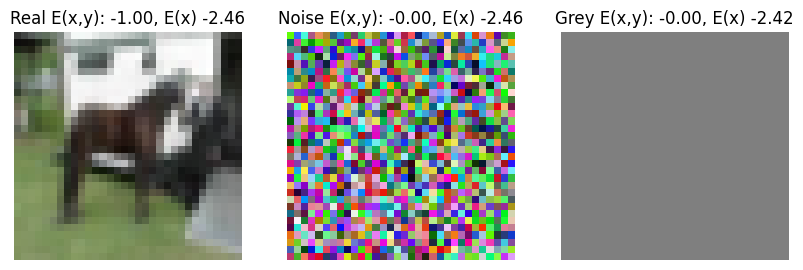

In [ ]:
# [Q6]
visualize_energy(model, 20)

### Sampling x

In [ ]:
# [C6]
def sampling_step(model : tf.keras.Model, data : tf.Tensor, label : tf.Tensor | None = None, step_size : float = 1, noise_amp : float = 0.01):
    # This forces the gradienttape to only track gradients for the input data:
    with tf.GradientTape(watch_accessed_variables = False) as g:
        g.watch(data)
        # calculate energy here (aggregate with sum)
        exy = energy(model, data, label)
        total_exy = tf.reduce_sum(exy)

    # calculate the gradient
    gradient = g.gradient(total_exy, data)

    # update data with gradient + gaussian noise
    data = data - step_size * gradient + noise_amp * tf.random.normal(tf.shape(data))

    # ensure that the sample is in the valid pixel space
    data = tf.clip_by_value(data, 0, 1)

    return data

### Replay Buffer

In [ ]:
# [C7]
class SampleBuffer:
    """ A buffer storing some past trained (negative) samples. """
    def __init__(self, sample_shape, n_class : int, max_samples : int = 10000, dtype : np.dtype = np.float32):
        self.max_samples = max_samples
        self.sample_shape = sample_shape
        self.n_class = n_class
        self.dtype = dtype
        self.buffer = []

    def add_to_buffer(self, samples, ids):
        """ Add samples to replay buffer (self.buffer). If there are too many samples in the buffer, remove the oldest ones (first in, first out). """
        samples = np.array(samples, dtype=self.dtype)
        ids = np.array(ids, dtype=np.int32)
        for x, y in zip(samples, ids):
            self.buffer.append((x, y))
            if len(self.buffer) > self.max_samples:
                self.buffer.pop(0)

    def sample_from_buffer(self, n_samples : int, p_new : float = 0.05):
        """ Sample batch of n_sample samples, with each sample being either new (with probability p_new) or from buffer."""
        images = []
        labels = []
        if len(self.buffer) == 0:
            images = np.random.uniform(0, 1, size=(n_samples, *self.sample_shape)).astype(self.dtype)
            labels = np.random.randint(0, self.n_class, size=n_samples)
        else:
            for i in range(n_samples):
                if np.random.rand() < p_new:
                    new_image = np.random.uniform(0, 1, size=self.sample_shape).astype(self.dtype)
                    new_label = np.random.randint(0, self.n_class)
                    images.append(new_image)
                    labels.append(new_label)
                else:
                    buffer_index = np.random.randint(len(self.buffer))
                    image, label = self.buffer[buffer_index]
                    images.append(image)
                    labels.append(label)
            images = np.array(images)
            labels = np.array(labels)

        return (images, labels)


In [ ]:
def visualize_buffer_samples(buffer : SampleBuffer, num_samples : int = 16, p_new : float = 0.05):
    # Retrieve samples and their corresponding labels from the buffer
    samples, labels = buffer.sample_from_buffer(num_samples, p_new)
    # Visualize the samples
    plt.figure(figsize=(10, 10))
    for i in range(num_samples):
        plt.subplot(4, 4, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(samples[i])  # Convert to uint8 for proper image display
        plt.xlabel(image_labels[labels[i]])
    plt.show()

sample_shape = X_train_p[0].shape
buffer = SampleBuffer(sample_shape, n_class)
# Add some initial data to the buffer
buffer.add_to_buffer(X_train_p[:100], Y_train_p[:100])  # Add first 100 samples as an example

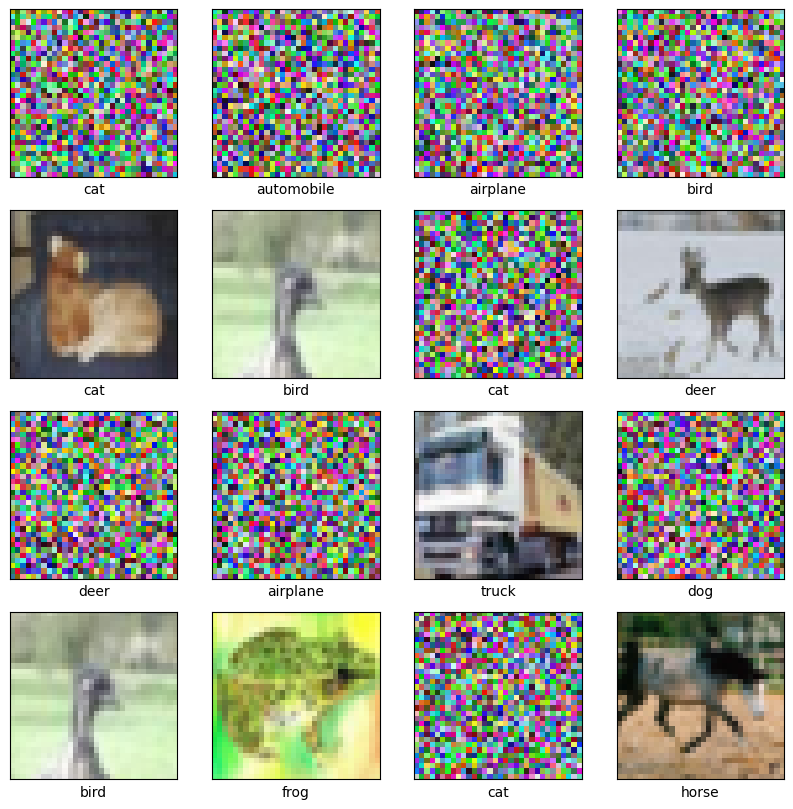

In [ ]:
#[Q8]
visualize_buffer_samples(buffer, num_samples=16, p_new=0.5)

### JEM Training

In [ ]:
#[C8]
def part2_train_step(optim : optimizers.Optimizer, model : tf.keras.Model, data : tf.Tensor, label : tf.Tensor, sb : SampleBuffer, sigma : float = 0.03) -> dict:
    batch_size = len(data)

    # preprocessing
    data_np = data.numpy()
    label_np = label.numpy()
    noise = np.random.normal(loc=0.0, scale=sigma, size=data_np.shape)
    data_noisy = data_np + noise
    x = np.clip(data_noisy, 0.0, 1.0)
    y = tf.keras.utils.to_categorical(label_np, num_classes=10)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    # sample images and labels (x', y') from SampleBuffer
    x_samp, y_samp = sb.sample_from_buffer(n_samples=batch_size)
    x_samp = tf.convert_to_tensor(x_samp, dtype=tf.float32)
    y_samp = tf.convert_to_tensor(y_samp, dtype=tf.int32)

    # run sampling step on x' 20 times, then add the final result back to the buffer
    for i in range(20):
        x_samp = sampling_step(model, x_samp, y_samp)
    sb.add_to_buffer(x_samp, y_samp)

    # train model
    with tf.GradientTape() as g:
        # calculate loss here, by:
        # 1. obtainig model output for x and x'
        logits_x = model(x, training=True)
        logits_x_samp = model(x_samp, training=True)

        # 2. calculate cross-entropy and energy values
        loss = tf.nn.sigmoid_cross_entropy_with_logits(logits=logits_x, labels=y)
        energy_x = energy(model, x)
        energy_x_samp = energy(model, x_samp)

        # 3. aggregate and calculate the final loss using the mentioned values
        total_loss = loss + tf.reduce_mean(energy_x) - tf.reduce_mean(energy_x_samp)

    # obtain the gradients and apply them (using optimizer)
    grads = g.gradient(loss, model.trainable_variables)
    optim.apply_gradients(zip(grads, model.trainable_variables))

    # return loss (or other values if needed)
    return {
        "loss": tf.reduce_mean(loss)
    }

In [ ]:
def train_loop_2(model, optimizer, train_step, epochs : int = 5, save_interval : int = 1, buffer : SampleBuffer | None = None) -> SampleBuffer:
    if buffer is None:
        buffer = SampleBuffer(X_train[0].shape, n_class)
    for epoch in range(1, epochs + 1):
        epoch_loss = 0
        num_batches = 0

        # Wrap the training dataset with tqdm to create a progress bar
        with tqdm(train_dataset, unit="batch") as tepoch:
            for step, (batch_x, batch_y) in enumerate(tepoch):
                # Execute a train step and get the losses
                loss_dict = train_step(optimizer, model, batch_x, batch_y, buffer)
                epoch_loss += loss_dict["loss"]

                # Accumulate number of batches (for average loss calculation)
                num_batches += 1

                # Update the progress bar description with the current loss
                tepoch.set_description(f"Epoch {epoch}")
                tepoch.set_postfix(**loss_dict)

        # Uncomment to test accuracy during training (Implement that first!)
        accuracy, misclassified_samples = evaluate_accuracy(model, test_dataset, False)
        print(f"Test Accuracy: {accuracy * 100:.2f}%")

        avg_loss = epoch_loss / num_batches
        print(f"Epoch {epoch}, Average Loss: {avg_loss:.4f}")

        # Feel free to modify this to save your progress somewhere else
        if epoch % save_interval == 0:
            model.save_weights(f'model-{epoch}.weights.h5')

    return buffer

### Execute training

In [ ]:
# Instantiate the model
model_2 = WRN(num_classes=n_class)

# Define the optimizer
optimizer_2 = optimizers.Adam(learning_rate=learning_rate)

If the training diverges, please restart the training

In [ ]:
# uncomment to run the code. I commend it as it takes too long to run the code. I afraid I may misclick it
buf = train_loop_2(model_2, optimizer_2, part2_train_step, 2)

  0%|          | 0/391 [00:00<?, ?batch/s]/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:372: UserWarning: `build()` was called on layer 'res_block_12', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:372: UserWarning: `build()` was called on layer 'res_block_13', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:372: UserWarning: `build()` was called on laye

Test Accuracy: 32.22%
Epoch 1, Average Loss: 0.7232


Epoch 2: 100%|██████████| 391/391 [18:21<00:00,  2.82s/batch, loss=tf.Tensor(0.7090375, shape=(), dtype=float32)]


Test Accuracy: 41.08%
Epoch 2, Average Loss: 0.7142


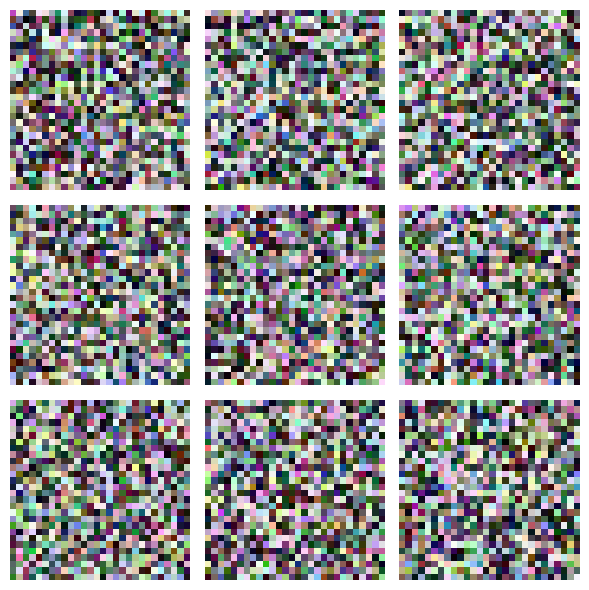

In [ ]:
#[B5]
img_shape = (28,28,1)
samples = tf.random.uniform((9, *img_shape), minval=0, maxval=1)
samples = tf.image.grayscale_to_rgb(samples)
samples = tf.convert_to_tensor(samples, dtype=tf.float32)

for i in range(200):
    samples = sampling_step(model, samples, label=None)

plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(samples[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

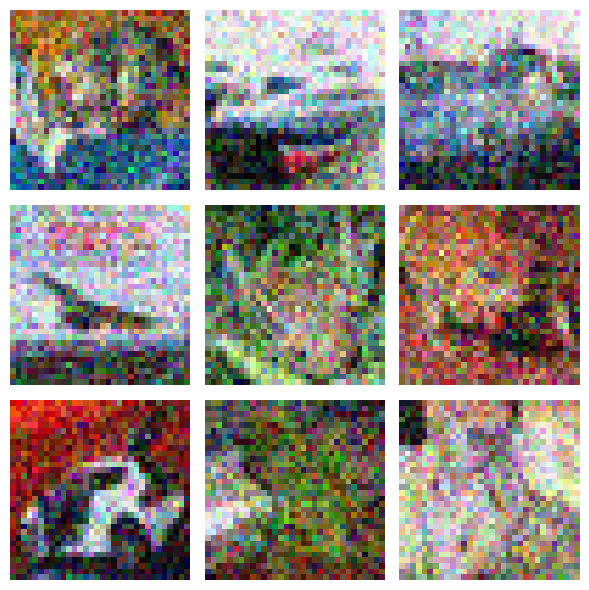

tf.Tensor(
[[0.08572771 0.08572771 0.08572771 0.08853322 0.08572771 0.08572771
  0.22564353 0.08572771 0.08572771 0.08572926]
 [0.0853382  0.23196611 0.08533695 0.08533695 0.08533695 0.08533695
  0.08533695 0.08533695 0.08533709 0.08533695]
 [0.08533674 0.08533674 0.08533674 0.08533674 0.08533674 0.08533674
  0.08533674 0.08533674 0.08533674 0.2319693 ]
 [0.08533675 0.08533675 0.08533675 0.08533675 0.08533675 0.08533675
  0.08533675 0.08533675 0.2319693  0.08533675]
 [0.08533675 0.08533675 0.08533675 0.08533675 0.08533675 0.08533675
  0.23196931 0.08533675 0.08533675 0.08533675]
 [0.08533675 0.08533675 0.08533675 0.08533682 0.0853368  0.08533675
  0.23196906 0.08533675 0.08533675 0.08533675]
 [0.08533953 0.08534484 0.08533953 0.08535231 0.08533953 0.08533953
  0.08534048 0.08533953 0.08533953 0.23192516]
 [0.08533675 0.08533675 0.08533675 0.08533675 0.08533675 0.08533675
  0.23196931 0.08533675 0.08533675 0.08533675]
 [0.08588585 0.08588585 0.08588585 0.22299705 0.08588703 0.08588859
 

In [ ]:
#[B6]
img_shape = (28,28,1)
samples = X_test_p[:9]
#samples = tf.image.grayscale_to_rgb(samples)
samples = tf.convert_to_tensor(samples, dtype=tf.float32)

for i in range(200):
    samples = sampling_step(model, samples, label=None, step_size=-1)

plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(samples[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

logits = model(samples)
probabilities = tf.nn.softmax(logits)
print(probabilities)

In [ ]:
#[B7 part 1]

# remove noise for part 1
# modify [C3] and run it, and then run part 1 training again
# [C3]
def part1_train_step(optim : optimizers.Optimizer, model : tf.keras.Model, data : tf.Tensor, label : tf.Tensor, sigma : float = 0.03) -> dict:
    data_np = data.numpy()
    label_np = label.numpy()

    # preprocessing
    noise = 0 # <------- modify here
    data_noisy = data_np + noise
    x = np.clip(data_noisy, 0.0, 1.0)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.keras.utils.to_categorical(label_np, num_classes=10)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    # train model
    with tf.GradientTape() as g:
        # calculate loss here
        logits = model(x)
        logits = tf.convert_to_tensor(logits, dtype=tf.float32)
        loss = tf.nn.sigmoid_cross_entropy_with_logits(logits=logits, labels=y)

    # obtain the gradients and apply them (using optimizer)
    grads = g.gradient(loss, model.trainable_variables)
    optim.apply_gradients(zip(grads, model.trainable_variables))

    # return loss (or other values if needed)
    return {
         "loss": tf.reduce_mean(loss)
    }

#=================================================================================================================================================
# remove noise for part 2
# modify [C8] and run it, and then run part 2 training again
#[C8]
def part2_train_step(optim : optimizers.Optimizer, model : tf.keras.Model, data : tf.Tensor, label : tf.Tensor, sb : SampleBuffer, sigma : float = 0.03) -> dict:
    batch_size = len(data)

    # preprocessing
    data_np = data.numpy()
    label_np = label.numpy()
    noise = 0 # <------- modify here
    data_noisy = data_np + noise
    x = np.clip(data_noisy, 0.0, 1.0)
    y = tf.keras.utils.to_categorical(label_np, num_classes=10)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    # sample images and labels (x', y') from SampleBuffer
    x_samp, y_samp = sb.sample_from_buffer(n_samples=batch_size)
    x_samp = tf.convert_to_tensor(x_samp, dtype=tf.float32)
    y_samp = tf.convert_to_tensor(y_samp, dtype=tf.int32)

    # run sampling step on x' 20 times, then add the final result back to the buffer
    for i in range(20):
        x_samp = sampling_step(model, x_samp, y_samp)
    sb.add_to_buffer(x_samp, y_samp)

    # train model
    with tf.GradientTape() as g:
        # calculate loss here, by:
        # 1. obtainig model output for x and x'
        logits_x = model(x, training=True)
        logits_x_samp = model(x_samp, training=True)

        # 2. calculate cross-entropy and energy values
        loss = tf.nn.sigmoid_cross_entropy_with_logits(logits=logits_x, labels=y)
        energy_x = energy(model, x)
        energy_x_samp = energy(model, x_samp)

        # 3. aggregate and calculate the final loss using the mentioned values
        total_loss = loss + tf.reduce_mean(energy_x) - tf.reduce_mean(energy_x_samp)

    # obtain the gradients and apply them (using optimizer)
    grads = g.gradient(loss, model.trainable_variables)
    optim.apply_gradients(zip(grads, model.trainable_variables))

    # return loss (or other values if needed)
    return {
        "loss": tf.reduce_mean(loss)
    }


In [ ]:
#[B7 part 2]
buf = train_loop_2(model, optimizer, part2_train_step, 2)

Epoch 1: 100%|██████████| 391/391 [18:21<00:00,  2.82s/batch, loss=tf.Tensor(0.68423796, shape=(), dtype=float32)]


Test Accuracy: 68.68%
Epoch 1, Average Loss: 0.6828


Epoch 2: 100%|██████████| 391/391 [17:15<00:00,  2.65s/batch, loss=tf.Tensor(0.68046767, shape=(), dtype=float32)]


Test Accuracy: 71.54%
Epoch 2, Average Loss: 0.6823


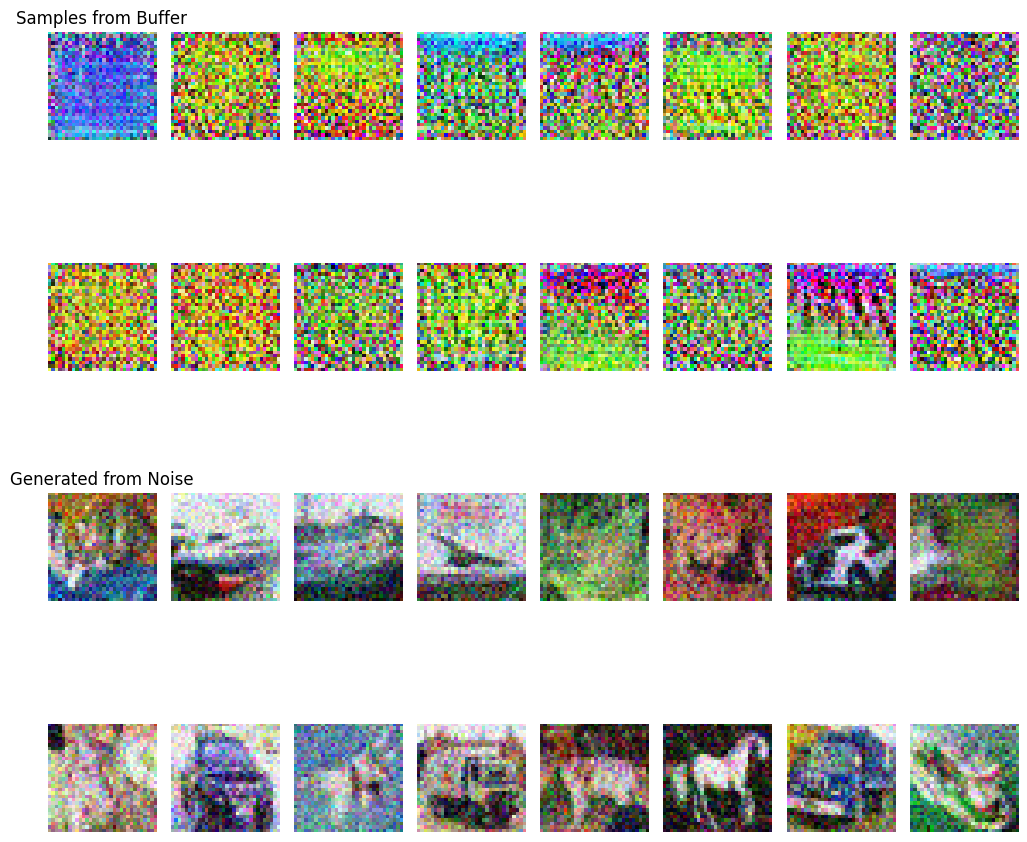

In [ ]:
#[B8]

buf_samples, buf_labels = buf.sample_from_buffer(16, 0.05)

img_shape = (28,28,1)
samples = X_test_p[:16]
#samples = tf.image.grayscale_to_rgb(samples)
samples = tf.convert_to_tensor(samples, dtype=tf.float32)

for i in range(200):
    samples = sampling_step(model_2, samples, label=None, step_size=1)

plt.figure(figsize=(10, 10))
plt.subplot(4, 8, 1)
plt.title("Samples from Buffer")
for i in range(16):
    plt.subplot(4, 8, i + 1)
    plt.imshow(buf_samples[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.subplot(4, 8, 17)
plt.title("Generated from Noise")
for i in range(16):
    plt.subplot(4, 8, 16 + i + 1)
    plt.imshow(samples[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

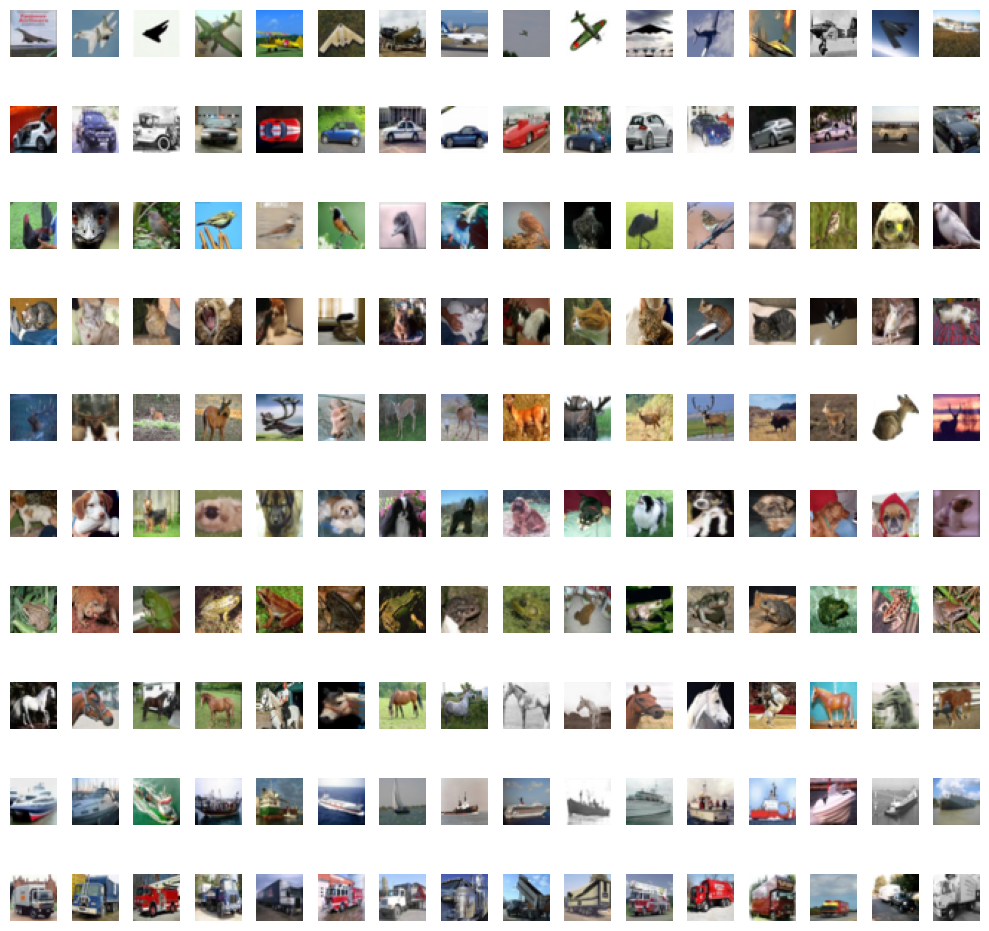

In [ ]:
#[B9]
# as the shape of the whole dataset is too large, and i am lasy to do batching on the data, so i only do 1 batch :)))
X_test_p_batch = X_test_p[:3000]
Y_test_p_batch = Y_test_p[:3000]
#X_test_p_batch = tf.convert_to_tensor(X_test_p_batch, dtype=tf.float32)
#Y_test_p_batch = tf.convert_to_tensor(Y_test_p_batch, dtype=tf.float32)

energies = energy(model_2, X_test_p_batch, label=None)
energy_label_pairs = list(zip(energies.numpy(), Y_test_p_batch))
top_samples_per_class = {i: [] for i in range(10)}
for en, label in energy_label_pairs:
    top_samples_per_class[label].append(en)
top_16_per_class = {k: sorted(v)[:16] for k, v in top_samples_per_class.items()}

plt.figure(figsize=(10, 10))
for class_label in range(10):
    for i in range(16):
        plt.subplot(10, 16, class_label * 16 + i + 1)
        sample = X_test_p_batch[Y_test_p_batch == class_label][i]
        plt.imshow(sample.squeeze(), cmap='gray')
        plt.axis('off')

plt.tight_layout()
plt.show()

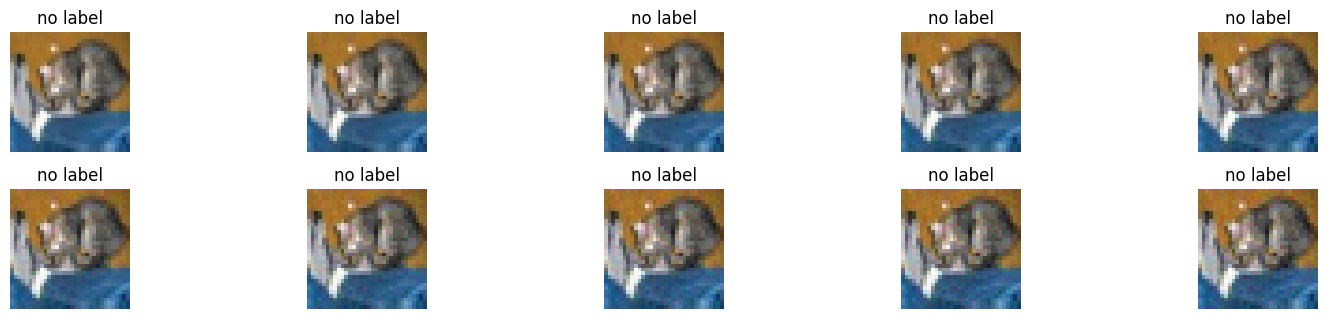

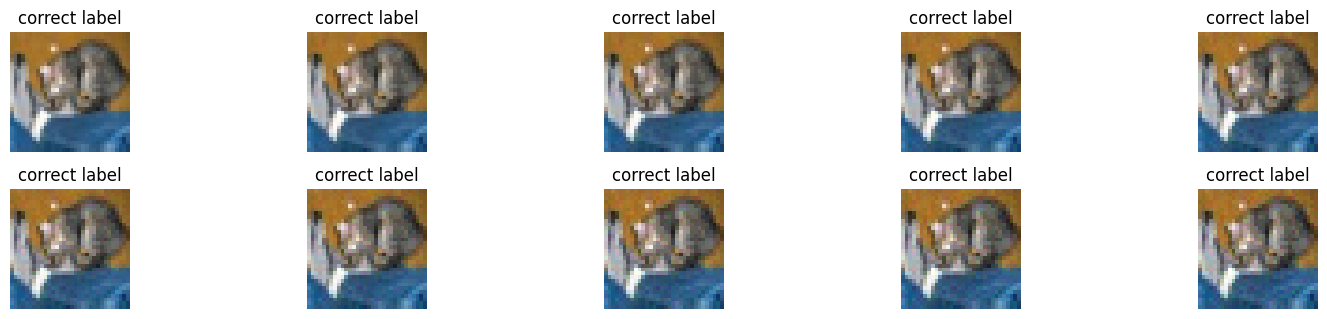

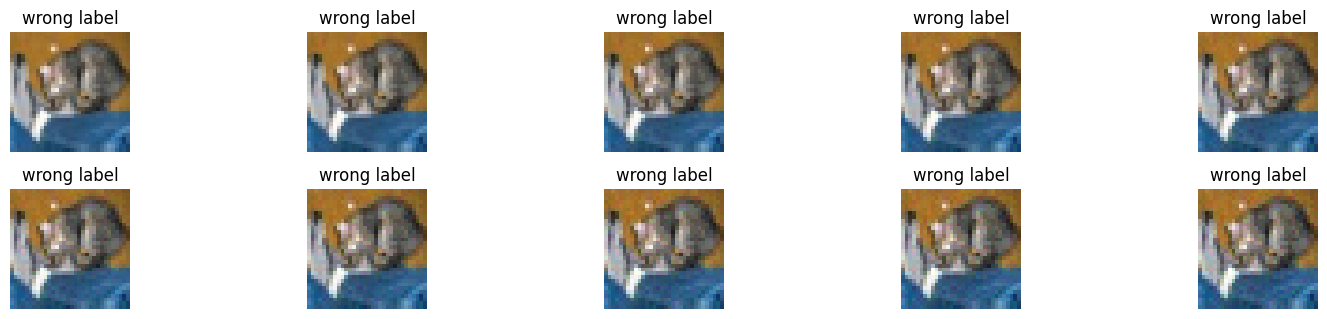

In [ ]:
#[B10]
original_image = X_test_p[:1]
original_image = tf.convert_to_tensor(original_image, dtype=tf.float32)
labels = [None, Y_test_p[:1], 0]
images_over_steps = [original_image]

for i in range(9):
    original_image = sampling_step(model, original_image, labels[0])
    images_over_steps.append(original_image)

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images_over_steps[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('no label')

plt.tight_layout()
plt.show()

for i in range(9):
    original_image = sampling_step(model, original_image, labels[1])
    images_over_steps.append(original_image)

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images_over_steps[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('correct label')

plt.tight_layout()
plt.show()

for i in range(9):
    original_image = sampling_step(model, original_image, labels[2])
    images_over_steps.append(original_image)

plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images_over_steps[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('wrong label')

plt.tight_layout()
plt.show()